<a href="https://colab.research.google.com/github/songwutsa/ColabProjects-Backup/blob/main/Copy_of_figure3_gistar_hotspots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# สร้างกราฟ Figure 3: Local Getis-Ord Gi* Hotspot Map (PM2.5)

**วัตถุประสงค์:** คำนวณค่า Getis-Ord Gi* local statistic (k-NN, k=5, บน log-transformed PM2.5) และสร้างกราฟแบบเดียวกับ Figure 3 ในต้นฉบับ — จุดสีตาม z-score, วงกลมแดงล้อมรอบจุดที่เป็น significant hotspot (p<0.05), และเพชร (diamond) ล้อมรอบจุด Tab Kwang (extreme value แต่ไม่ significant)

**อินพุตที่ต้องเตรียม:**
1. ไฟล์พิกัด 32 ไซต์ (คอลัมน์ `site_id`, `lat`, `lon`) — ใช้ไฟล์ `site_coordinates_resolved.csv` ที่มีอยู่แล้วได้เลย
2. ไฟล์ข้อมูล PM2.5 (ไฟล์ Excel ต้นฉบับ "บันทึกการตรวจวัดปริมาณฝุ่น.xlsx" หรือไฟล์ CSV ที่มีคอลัมน์ site_id และ PM2.5)


## ขั้นตอนที่ 1: ติดตั้งไลบรารีที่จำเป็น

In [ ]:
!pip install libpysal esda geopandas matplotlib --quiet
print("ติดตั้งเสร็จแล้ว")


ติดตั้งเสร็จแล้ว


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from libpysal.weights import KNN
from esda.getisord import G_Local
from google.colab import files

print("นำเข้าไลบรารีสำเร็จ")


นำเข้าไลบรารีสำเร็จ


## ขั้นตอนที่ 2: อัปโหลดไฟล์พิกัด 32 ไซต์

เลือกไฟล์ `site_coordinates_resolved.csv` (คอลัมน์ `site_id`, `lat`, `lon`)


In [ ]:
uploaded = files.upload()
coords_filename = list(uploaded.keys())[0]
coords = pd.read_csv(coords_filename)
coords = coords[['site_id', 'lat', 'lon']].dropna().reset_index(drop=True)
print(f"จำนวนไซต์ที่มีพิกัด: {len(coords)}")
coords.head()


Saving site_coordinates_resolved.csv to site_coordinates_resolved.csv
จำนวนไซต์ที่มีพิกัด: 32


,site_id,lat,lon
0,จุดตรวจวัดอากาศ-1,15.132970,100.603782
1,จุดตรวจวัดอากาศ-2,15.132317,100.860427
2,จุดตรวจวัดอากาศ-3,15.131391,101.114891
3,จุดตรวจวัดอากาศ-4,15.130189,101.371070
4,จุดตรวจวัดอากาศ-5,15.128612,101.627133


## ขั้นตอนที่ 3: อัปโหลดไฟล์ข้อมูล PM2.5

เลือกไฟล์ Excel/CSV ที่มีค่า PM2.5 ต่อไซต์ (เช่นไฟล์บันทึกการตรวจวัดต้นฉบับ)


In [ ]:
uploaded2 = files.upload()
pm_filename = list(uploaded2.keys())[0]

if pm_filename.lower().endswith(('.xlsx', '.xls')):
    pm_raw = pd.read_excel(pm_filename, header=0)
else:
    pm_raw = pd.read_csv(pm_filename)

print("คอลัมน์ที่พบ:")
print(list(pm_raw.columns))
pm_raw.head(3)


Saving บันทึกการตรวจวัดปริมาณฝุ่น.xlsx to บันทึกการตรวจวัดปริมาณฝุ่น.xlsx
คอลัมน์ที่พบ:
['Unnamed: 0', 'พิกัด', 'ที่อยู่', 'PM0.30 (µg/m3)', 'PM0.50 (µg/m3)', 'PM1.00 (µg/m3)', 'PM2.5 (µg/m3)', 'PM5.0 (µg/m3)', 'PM10.0 (µg/m3)', 'TPM (µg/m3)', 'RH(%)', 'Temp (oC)', 'ทิศทางลม', 'วันที่ตรวจวัด', 'เวลาที่อ่านค่า', 'จำนวนป่วยโรคที่เกี่ยวข้องกับมลพิษทางอากาศ ปี 2566(ราย)', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']


,Unnamed: 0,พิกัด,ที่อยู่,PM0.30 (µg/m3),PM0.50 (µg/m3),PM1.00 (µg/m3),PM2.5 (µg/m3),PM5.0 (µg/m3),PM10.0 (µg/m3),TPM (µg/m3),...,Temp (oC),ทิศทางลม,วันที่ตรวจวัด,เวลาที่อ่านค่า,จำนวนป่วยโรคที่เกี่ยวข้องกับมลพิษทางอากาศ ปี 2566(ราย),Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,ม.ค.,ก.พ.,มี.ค.,เม.ย.,พ.ค.,มิ.ย.
1,จุดตรวจวัดอากาศ-1,https://goo.gl/maps/WfoDxiiEE7WW73dg7,ตำบล ดอนดึง อำเภอ บ้านหมี่ ลพบุรี,5.25,2.18,6.16,14.62,14.62,19.49,62.32,...,31.6,SW->NE,5/6/66,13:40:00,3,1,5,14,3,4
2,จุดตรวจวัดอากาศ-2,https://goo.gl/maps/ki5HpmiGYmLMLehp6,ตำบล ดงมะรุม อำเภอ โคกสำโรง ลพบุรี,3.36,1.14,4.61,13.82,13.82,27.64,64.38,...,26.7,SW->NE,29/6/66,1900-01-11 11:14:00,8,12,22,16,17,3


## ขั้นตอนที่ 4: ระบุคอลัมน์ชื่อไซต์และค่า PM2.5

แก้ชื่อคอลัมน์ด้านล่างให้ตรงกับไฟล์ของคุณ ถ้าเดาไม่ตรงให้แก้เอง


In [ ]:
def guess_col(columns, keywords):
    for c in columns:
        cl = str(c).lower()
        for kw in keywords:
            if kw in cl or kw in str(c):
                return c
    return None

SITE_COL = guess_col(pm_raw.columns, ['site', 'จุดตรวจวัด', 'id']) or pm_raw.columns[0]
PM_COL = guess_col(pm_raw.columns, ['pm2.5', 'pm 2.5', 'pm25'])

print(f"คอลัมน์ชื่อไซต์: {SITE_COL}")
print(f"คอลัมน์ PM2.5: {PM_COL}")

pm_df = pm_raw[[SITE_COL, PM_COL]].dropna().reset_index(drop=True)
pm_df.columns = ['site_id', 'pm25']
pm_df.head()


คอลัมน์ชื่อไซต์: Unnamed: 0
คอลัมน์ PM2.5: PM2.5 (µg/m3)


,site_id,pm25
0,จุดตรวจวัดอากาศ-1,14.62
1,จุดตรวจวัดอากาศ-2,13.82
2,จุดตรวจวัดอากาศ-3,20.54
3,จุดตรวจวัดอากาศ-4,12.82
4,จุดตรวจวัดอากาศ-5,22.62


## ขั้นตอนที่ 5: รวมข้อมูลพิกัดกับ PM2.5


In [ ]:
data = pd.merge(coords, pm_df, on='site_id', how='inner')
print(f"จำนวนไซต์ที่รวมข้อมูลสำเร็จ: {len(data)} จากทั้งหมด {len(coords)}")

if len(data) < len(coords):
    missing = set(coords['site_id']) - set(data['site_id'])
    print(f"⚠️ ไซต์ที่จับคู่ไม่ได้ (ชื่ออาจไม่ตรงกันระหว่าง 2 ไฟล์): {missing}")

data['log_pm25'] = np.log(data['pm25'])
data.head()


จำนวนไซต์ที่รวมข้อมูลสำเร็จ: 32 จากทั้งหมด 32


,site_id,lat,lon,pm25,log_pm25
0,จุดตรวจวัดอากาศ-1,15.132970,100.603782,14.62,2.682390
1,จุดตรวจวัดอากาศ-2,15.132317,100.860427,13.82,2.626117
2,จุดตรวจวัดอากาศ-3,15.131391,101.114891,20.54,3.022374
3,จุดตรวจวัดอากาศ-4,15.130189,101.371070,12.82,2.551006
4,จุดตรวจวัดอากาศ-5,15.128612,101.627133,22.62,3.118834


## ขั้นตอนที่ 6: แปลงพิกัดเป็น UTM (EPSG:32647) แล้วสร้าง k-NN Spatial Weights (k=5)

ใช้ระบบพิกัด UTM เพื่อให้ระยะทางระหว่างจุดถูกต้องตามจริง (หน่วยเมตร) ก่อนหาเพื่อนบ้านใกล้ที่สุด 5 จุด


In [ ]:
gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data['lon'], data['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32647')

coords_utm = np.column_stack([gdf.geometry.x, gdf.geometry.y])

w = KNN.from_array(coords_utm, k=5)
w.transform = 'B'  # binary weights ตามที่ระบุใน manuscript (k-NN, k=5)
print(f"สร้าง spatial weights สำเร็จ: {w.n} ไซต์, k=5 เพื่อนบ้านต่อจุด")


สร้าง spatial weights สำเร็จ: 32 ไซต์, k=5 เพื่อนบ้านต่อจุด


## ขั้นตอนที่ 7: คำนวณ Getis-Ord Gi* (Local, star=True)

`star=True` หมายถึงรวมจุดตัวเองเข้าไปในการคำนวณด้วย (Gi* ตามนิยามดั้งเดิม)


In [ ]:
np.random.seed(12345)  # กำหนด seed เพื่อให้ผล permutation-based p-value ทำซ้ำได้

gi_star = G_Local(data['log_pm25'].values, w, transform='B', star=True, permutations=999)

data['gi_star_z'] = gi_star.Zs
data['gi_star_p_sim'] = gi_star.p_sim
data['significant_hotspot'] = (data['gi_star_z'] > 1.96) & (data['gi_star_p_sim'] < 0.05)

print(f"จำนวน significant hotspots (z>1.96, p<0.05): {data['significant_hotspot'].sum()}")
data[['site_id', 'pm25', 'gi_star_z', 'gi_star_p_sim', 'significant_hotspot']].sort_values('gi_star_z', ascending=False)


จำนวน significant hotspots (z>1.96, p<0.05): 4


,site_id,pm25,gi_star_z,gi_star_p_sim,significant_hotspot
11,จุดตรวจวัดอากาศ-12,54.11,3.161659,0.007,True
26,จุดตรวจวัดอากาศ-survey-1,21.51,3.085120,0.004,True
25,จุดตรวจวัดอากาศ-survey-0,18.21,2.642080,0.009,True
12,จุดตรวจวัดอากาศ-13,486.15,2.251105,0.159,False
27,จุดตรวจวัดอากาศ-survey-2,29.51,2.251105,0.043,True
28,จุดตรวจวัดอากาศ-survey-3,43.71,1.778165,0.142,False
10,จุดตรวจวัดอากาศ-11,49.41,0.383809,0.439,False
5,จุดตรวจวัดอากาศ-6,27.29,0.332648,0.305,False
15,จุดตรวจวัดอากาศ-16,10.20,0.264240,0.215,False
13,จุดตรวจวัดอากาศ-14,16.68,0.120201,0.317,False


## ขั้นตอนที่ 8: ระบุจุด Tab Kwang (extreme value แต่ไม่ significant)

แก้ชื่อไซต์ด้านล่างให้ตรงกับ site_id ของ Tab Kwang ในข้อมูลของคุณ (ค่าเริ่มต้นคือ "จุดตรวจวัดอากาศ-13" ตามที่ระบุไว้ในต้นฉบับ)


In [ ]:
TAB_KWANG_SITE_ID = 'จุดตรวจวัดอากาศ-13'

if TAB_KWANG_SITE_ID not in data['site_id'].values:
    print(f"⚠️ ไม่พบ site_id '{TAB_KWANG_SITE_ID}' ในข้อมูล กรุณาตรวจสอบและแก้ไขตัวแปร TAB_KWANG_SITE_ID ด้านบน")
    print("รายชื่อ site_id ที่มีอยู่:", sorted(data['site_id'].tolist()))
else:
    tk_row = data[data['site_id'] == TAB_KWANG_SITE_ID].iloc[0]
    print(f"Tab Kwang: PM2.5={tk_row['pm25']:.2f}, Gi* z-score={tk_row['gi_star_z']:.2f}, "
          f"significant={tk_row['significant_hotspot']}")


Tab Kwang: PM2.5=486.15, Gi* z-score=2.25, significant=False


## ขั้นตอนที่ 9: วาดกราฟ Figure 3


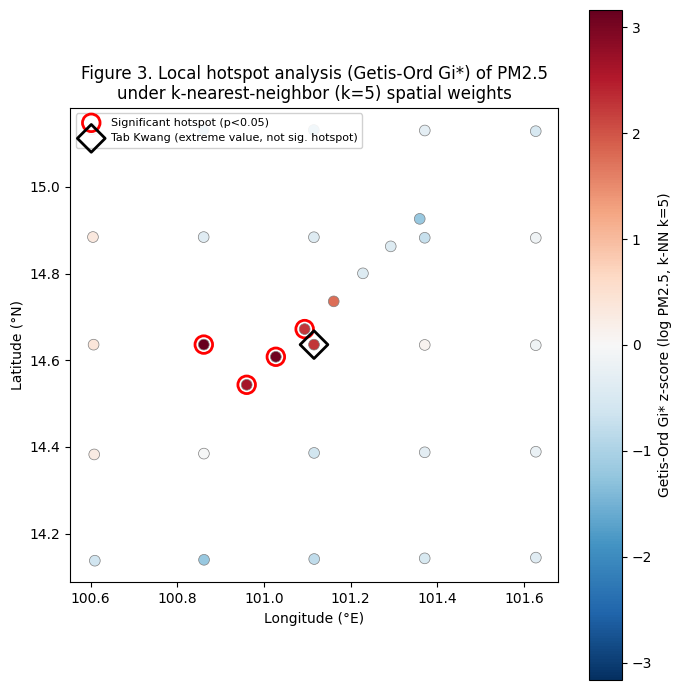

บันทึกภาพ: figure3_gistar_hotspots.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

vmax = max(abs(data['gi_star_z'].min()), abs(data['gi_star_z'].max()))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

sc = ax.scatter(
    data['lon'], data['lat'],
    c=data['gi_star_z'], cmap='RdBu_r', norm=norm,
    s=60, edgecolors='gray', linewidths=0.5, zorder=2
)

# วงกลมแดงล้อมรอบ significant hotspots
hotspots = data[data['significant_hotspot']]
ax.scatter(
    hotspots['lon'], hotspots['lat'],
    facecolors='none', edgecolors='red', s=160, linewidths=2,
    label='Significant hotspot (p<0.05)', zorder=3
)

# เพชรล้อมรอบ Tab Kwang
if TAB_KWANG_SITE_ID in data['site_id'].values:
    tk_row = data[data['site_id'] == TAB_KWANG_SITE_ID].iloc[0]
    ax.scatter(
        [tk_row['lon']], [tk_row['lat']],
        facecolors='none', edgecolors='black', marker='D', s=200, linewidths=2,
        label='Tab Kwang (extreme value, not sig. hotspot)', zorder=3
    )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Getis-Ord Gi* z-score (log PM2.5, k-NN k=5)')

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Figure 3. Local hotspot analysis (Getis-Ord Gi*) of PM2.5\nunder k-nearest-neighbor (k=5) spatial weights')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('figure3_gistar_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()
print("บันทึกภาพ: figure3_gistar_hotspots.png")


## ขั้นตอนที่ 10: ดาวน์โหลดภาพและข้อมูลผลลัพธ์


In [ ]:
files.download('figure3_gistar_hotspots.png')

output_csv = 'gistar_results.csv'
data[['site_id', 'lat', 'lon', 'pm25', 'log_pm25', 'gi_star_z', 'gi_star_p_sim', 'significant_hotspot']].to_csv(
    output_csv, index=False, encoding='utf-8-sig'
)
files.download(output_csv)
print(f"บันทึกไฟล์: {output_csv}")


## หมายเหตุสำคัญ

- ค่า z-score ที่ได้ (`Zs`) เป็นค่าที่คำนวณได้แบบ analytic (deterministic) จะตรงกับต้นฉบับเสมอถ้าข้อมูลนำเข้าตรงกัน แต่ **ค่า p-value จาก permutation (`p_sim`)** อาจมีความคลาดเคลื่อนเล็กน้อยจากการสุ่มแต่ละครั้ง แม้จะกำหนด `random seed` ไว้แล้วก็ตาม (ถ้าต้องการ p-value แบบ analytic ให้ใช้ `gi_star.p_norm` แทน)
- ถ้าจำนวน significant hotspots หรือค่า z-score ที่ได้ไม่ตรงกับที่รายงานในต้นฉบับ (3 hotspots: z=2.89, 3.27, 2.22) ให้ตรวจสอบว่า:
  1. ใช้ log(PM2.5) ถูกต้องหรือไม่ (ธรรมชาติ log ฐาน e ตามที่ใช้ในสคริปต์นี้)
  2. spatial weights ใช้ k-NN k=5 และแปลงเป็น binary (`transform='B'`) ตรงตามที่ระบุในต้นฉบับ
  3. พิกัดที่ใช้ตรงกับที่ใช้ในการวิเคราะห์ต้นฉบับหรือไม่
- ปรับแต่งสี ขนาดจุด หรือ layout ของกราฟได้ที่ขั้นตอนที่ 9 ตามความต้องการ
